# Feature Engineering v1

Objective:

Build ATR-based volatility compression features for range detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_v1.csv", parse_dates=["date"], index_col="date")

df.head()

,open,high,low,close,tick_volume,spread,returns,log_returns
date,,,,,,,,
2022-10-25 01:00:00,0.98701,0.98875,0.98700,0.98868,2464,0,0.001651,0.001650
2022-10-25 02:00:00,0.98868,0.98904,0.98836,0.98843,2428,0,-0.000253,-0.000253
2022-10-25 03:00:00,0.98843,0.98972,0.98787,0.98943,7115,0,0.001012,0.001011
2022-10-25 04:00:00,0.98943,0.98986,0.98773,0.98878,9177,0,-0.000657,-0.000657
2022-10-25 05:00:00,0.98879,0.98898,0.98782,0.98846,5202,0,-0.000324,-0.000324


In [3]:
tr1 = df["high"] - df["low"]

tr2 = abs(df["high"] - df["close"].shift(1))

tr3 = abs(df["low"] - df["close"].shift(1))

In [4]:
df["tr"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

df["tr"].head()

date
2022-10-25 01:00:00    0.00175
2022-10-25 02:00:00    0.00068
2022-10-25 03:00:00    0.00185
2022-10-25 04:00:00    0.00213
2022-10-25 05:00:00    0.00116
Name: tr, dtype: float64

In [5]:
df["atr_14"] = df["tr"].rolling(14).mean()

df["atr_14"].head(20)

date
2022-10-25 01:00:00         NaN
2022-10-25 02:00:00         NaN
2022-10-25 03:00:00         NaN
2022-10-25 04:00:00         NaN
2022-10-25 05:00:00         NaN
2022-10-25 06:00:00         NaN
2022-10-25 07:00:00         NaN
2022-10-25 08:00:00         NaN
2022-10-25 09:00:00         NaN
2022-10-25 10:00:00         NaN
2022-10-25 11:00:00         NaN
2022-10-25 12:00:00         NaN
2022-10-25 13:00:00         NaN
2022-10-25 14:00:00    0.001602
2022-10-25 15:00:00    0.001616
2022-10-25 16:00:00    0.002256
2022-10-25 17:00:00    0.002420
2022-10-25 18:00:00    0.002441
2022-10-25 19:00:00    0.002492
2022-10-25 20:00:00    0.002542
Name: atr_14, dtype: float64

In [6]:
df[["tr", "atr_14"]].tail()

,tr,atr_14
date,,
2025-11-14 19:00:00,0.00106,0.001506
2025-11-14 20:00:00,0.00088,0.001530
2025-11-14 21:00:00,0.00043,0.001495
2025-11-14 22:00:00,0.00064,0.001427
2025-11-14 23:00:00,0.00066,0.001372


In [7]:
df["atr_mean_16"] = df["atr_14"].rolling(16).mean()
df["atr_mean_48"] = df["atr_14"].rolling(48).mean()

In [8]:
df[["atr_14", "atr_mean_16", "atr_mean_48"]].tail()

,atr_14,atr_mean_16,atr_mean_48
date,,,
2025-11-14 19:00:00,0.001506,0.001171,0.001165
2025-11-14 20:00:00,0.001530,0.001197,0.001175
2025-11-14 21:00:00,0.001495,0.001223,0.001184
2025-11-14 22:00:00,0.001427,0.001249,0.001192
2025-11-14 23:00:00,0.001372,0.001276,0.001198


In [9]:
df["atr_rel_16"] = df["atr_14"] / df["atr_mean_16"]
df["atr_rel_48"] = df["atr_14"] / df["atr_mean_48"]

In [10]:
df[["atr_rel_16", "atr_rel_48"]].tail()

,atr_rel_16,atr_rel_48
date,,
2025-11-14 19:00:00,1.286221,1.292609
2025-11-14 20:00:00,1.277757,1.302359
2025-11-14 21:00:00,1.222234,1.262983
2025-11-14 22:00:00,1.142898,1.197767
2025-11-14 23:00:00,1.075588,1.145384


In [11]:
df = df.dropna()
df.isnull().sum()

open           0
high           0
low            0
close          0
tick_volume    0
spread         0
returns        0
log_returns    0
tr             0
atr_14         0
atr_mean_16    0
atr_mean_48    0
atr_rel_16     0
atr_rel_48     0
dtype: int64

In [12]:
df[["atr_rel_16", "atr_rel_48"]].describe()

,atr_rel_16,atr_rel_48
count,18966.000000,18966.000000
mean,1.016185,1.006237
std,0.273390,0.286478
min,0.389409,0.408323
25%,0.804685,0.788887
50%,0.990897,0.973000
75%,1.211204,1.179809
max,2.268809,2.958152


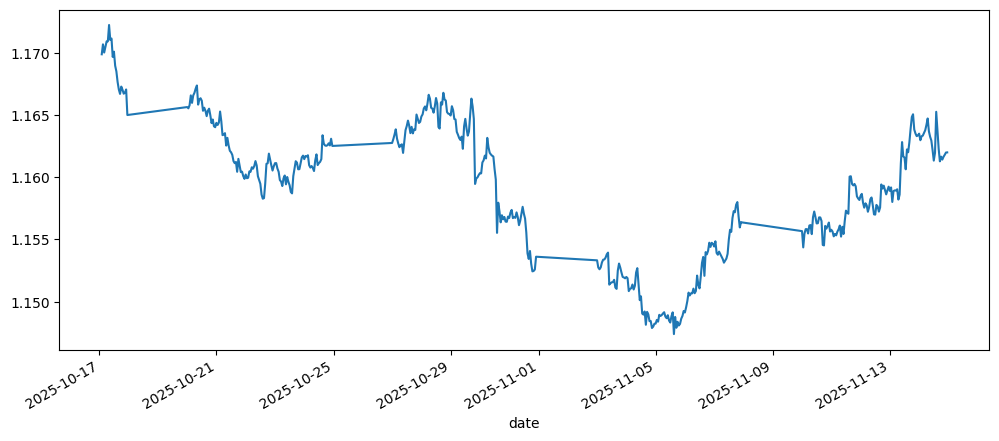

In [13]:
df["close"].iloc[-500:].plot(figsize=(12,5))
plt.show()

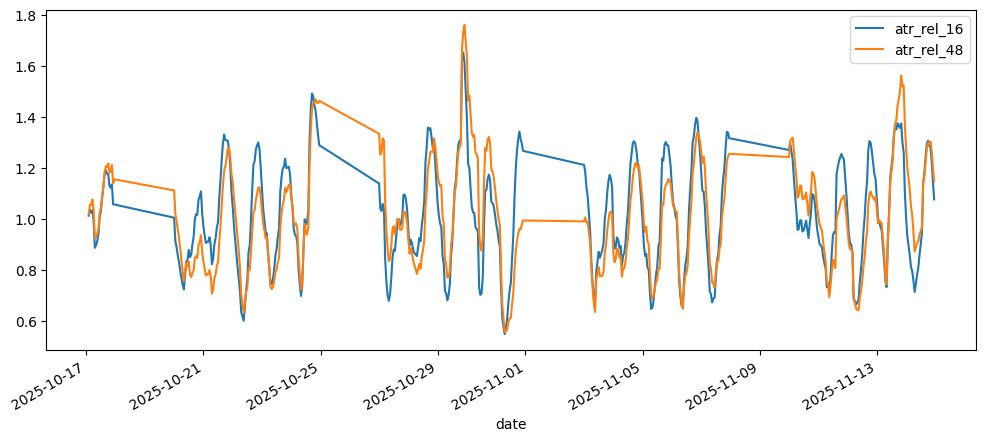

In [14]:
df[["atr_rel_16","atr_rel_48"]].iloc[-500:].plot(figsize=(12,5))
plt.show()

In [15]:
df.to_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v1.csv")